# Train YOLO Models in Google Colab for use with drone camera

# Introduction

This notebook uses [Ultralytics](https://docs.ultralytics.com/) to train YOLOv8 object detection models with a custom dataset. At the end of this Colab, you'll have a custom YOLO model that you can run on windows PC using onnxdetector.

**Important note: This notebook will be continuously updated to make sure it works with newer versions of Ultralytics and YOLO. Always follow the notebook!**

### Working in Colab
Google Colab provides a virtual machine in your browser complete with a Linux OS, filesystem, Python environment, and best of all, a free GPU. We'll install PyTorch and Ultralytics in this environment and use it to train our model. Simply click the Play button on sections of code in this notebook to execute them on the virtual machine.

### Navigation
To navigate this notebook, use the table of contents in the left sidebar to jump from section to section.





**Verify NVIDIA GPU Availability**

Make sure you're using a GPU-equipped machine by going to "Runtime" -> "Change runtime type" in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section. Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.

In [1]:
!nvidia-smi

Sat May 16 09:33:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#1.&nbsp;Gather and Label Training Images

Before we start training, we need to gather and label images that will be used for training the object detection model. A good starting point for a proof-of-concept model is 200 images. The training images should have random objects in the image along with the desired objects, and should have a variety of backgrounds and lighting conditions. See video to learn more : https://youtu.be/v0ssiOY6cfg?si=n7t8oBvzOjlHX9Nc


Build a custom dataset by taking your own pictures of the objects and labeling them (this typically results in the best performance). There are several tools available for labeling images. One good option is labelimg, a free and open-source labeling tool that has a simple workflow while providing capabilities for more advanced features.

<p align=center>
<img src="https://www.researchgate.net/profile/Meizano-Muhammad/publication/357260479/figure/fig3/AS:1119809194475521@1643994725344/Labeling-using-labelImg.png" height="380"><br>
<i>Example of a candy image labeled with Label Studio.</i>
</p>

If you used labelimg to label and export the images, they'll be exported in a `project.zip` file that contains the following:

- An `images` folder containing the images
- A `labels` folder containing the labels in YOLO annotation format
- A `classes.txt` labelmap file that contains all the classes

<p align=center>
<img src="https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/doc/zipped-data-example.png" height=""><br>
<i>Organize your data in the folders shown here.
</p>

Once you've got your dataset built, put into the file structure shown above, and zipped into `data.zip`, you're ready to move on to the next step.

# 2.&nbsp;Upload Image Dataset and Prepare Training Data

Next, we'll upload our dataset and prepare it for training with YOLO. We'll split the dataset into train and validation folders, and we'll automatically generate the configuration file for training the model.

## 2.1 Upload images

First, we need to upload the dataset to Colab. Here are a few options for moving the `data.zip` folder into this Colab instance.

**Option 1. Upload through Google Colab**

Upload the `data.zip` file to the Google Colab instance by clicking the "Files" icon on the left hand side of the browser, and then the "Upload to session storage" icon. Select the zip folder to upload it.

<p>
<br>
<img src="https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/doc/upload-colab-files.png" height="240">
</p>



**Option 2. Copy from Google Drive**

You can also upload your images to your personal Google Drive, mount the drive on this Colab session, and copy them over to the Colab filesystem. This option works well if you want to upload the images beforehand so you don't have to wait for them to upload each time you restart this Colab. If you have more than 50MB worth of images, I recommend using this option.

First, upload the `data.zip` file to your Google Drive, and make note of the folder you uploaded them to. Replace `MyDrive/path/to/data.zip` with the path to your zip file. (For example, I uploaded the zip file to folder called "candy-dataset1", so I would use `MyDrive/candy-dataset1/data.zip` for the path). Then, run the following block of code to mount your Google Drive to this Colab session and copy the folder to this filesystem.

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

# !cp /content/gdrive/MyDrive/path/to/data.zip /content
!cp "/content/gdrive/MyDrive/NUS Notes/Year 4 Sem 2/DSTA Brainhack/data.zip" /content/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2.2 Split images into train and validation folders

At this point, whether you used Option 1, or 2, you should be able to click the folder icon on the left and see your `data.zip` file in the list of files. Next, we'll unzip `data.zip` and create some folders to hold the images. Run the following code block to unzip the data.

In [3]:
# Unzip images to a custom data folder
!unzip -q /content/data.zip -d /content/custom_data

replace /content/custom_data/images/frame_0000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


Ultralytics requires a particular folder structure to store training data for models. Ultralytics requires a particular folder structure to store training data for models. The root folder is named “data”. Inside, there are two main folders:

*   **Train**: These are the actual images used to train the model. In one epoch of training, every image in the train set is passed into the neural network. The training algorithm adjusts the network weights to fit the data in the images.


*   **Validation**: These images are used to check the model's performance at the end of each training epoch.

In each of these folders is a “images” folder and a “labels” folder, which hold the image files and annotation files respectively.

Let us use a Python script to automatically create the required folder structure and randomly move 90% of dataset to the "train" folder and 10% to the "validation" folder. Run the following code block to download and execute the scrpt.

In [4]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

# TO DO: Improve robustness of train_val_split.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2026-05-16 09:33:20--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2026-05-16 09:33:20 (61.9 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Number of image files: 216
Number of annotation files: 216
Images moving to train: 194
Images moving to validation: 22


# 3.&nbsp;Install Requirements (Ultralytics)

Next, we'll install the Ultralytics library in this Google Colab instance. This Python library will be used to train the YOLO model.

In [5]:
!pip install ultralytics

# 4.&nbsp;Configure Training


There's one last step before we can run training: we need to create the Ultralytics training configuration YAML file. This file specifies the location of your train and validation data, and it also defines the model's classes. An example configuration file model is available [here](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml).

Run the code block below to automatically generate a `data.yaml` configuration file. Make sure you have a labelmap file located at `custom_data/classes.txt`. If you used Label Studio, it should already be present. If you assembled the dataset another way, you may have to manually create the `classes.txt` file (see [here](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/doc/classes.txt) for an example of how it's formatted).

In [6]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 3
names:
- yellow barrel
- red barrel
- toxic barrel


# 5.&nbsp;Train Model

## 5.1 Training Parameters
Now that the data is organized and the config file is created, we're ready to start training! First, there are a few important parameters to decide on.

**Model architecture & size (`model`):**

There are several YOLO8 models sizes available to train, including `yolov8n.pt`, `yolov8s.pt`, `yolov8m.pt`, `yolov8l.pt`, and `yolov8x.pt` (from smallest to largest). Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy. If you aren't sure which model size to use, `yolov8n.pt` is a good starting point.


**Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.


**Resolution (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution.


## 5.2 Run Training!

Run the following code block to begin training. If you want to use a different model, number of epochs, or resolution, change `model`, `epochs`, or `imgsz`.

In [7]:
# !yolo detect train data=/content/data.yaml model=yolo11m.pt epochs=100 imgsz=640
!yolo detect train data=/content/data.yaml model=yolov8n.pt epochs=40 imgsz=640

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each epoch. Training will end once it goes through the number of epochs specified by `epochs`.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

#6.&nbsp;Test Model

The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.

In [8]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

image 1/86 /content/data/validation/images/frame_0001.jpg: 384x640 3 toxic barrels, 44.6ms
image 2/86 /content/data/validation/images/frame_0063.jpg: 384x640 (no detections), 6.5ms
image 3/86 /content/data/validation/images/frame_0093.jpg: 384x640 (no detections), 5.8ms
image 4/86 /content/data/validation/images/frame_0100.jpg: 384x640 1 red barrel, 6.4ms
image 5/86 /content/data/validation/images/frame_0101.jpg: 384x640 1 red barrel, 6.4ms
image 6/86 /content/data/validation/images/frame_0113.jpg: 384x640 1 yellow barrel, 1 red barrel, 6.0ms
image 7/86 /content/data/validation/images/frame_0114.jpg: 384x640 1 yellow barrel, 1 red barrel, 5.9ms
image 8/86 /content/data/validation/images/frame_0122.jpg: 384x640 1 yellow barrel, 1 red barrel, 9.3ms
image 9/86 /content/data/validation/images/frame_0153.jpg: 384x640 4 toxic barr

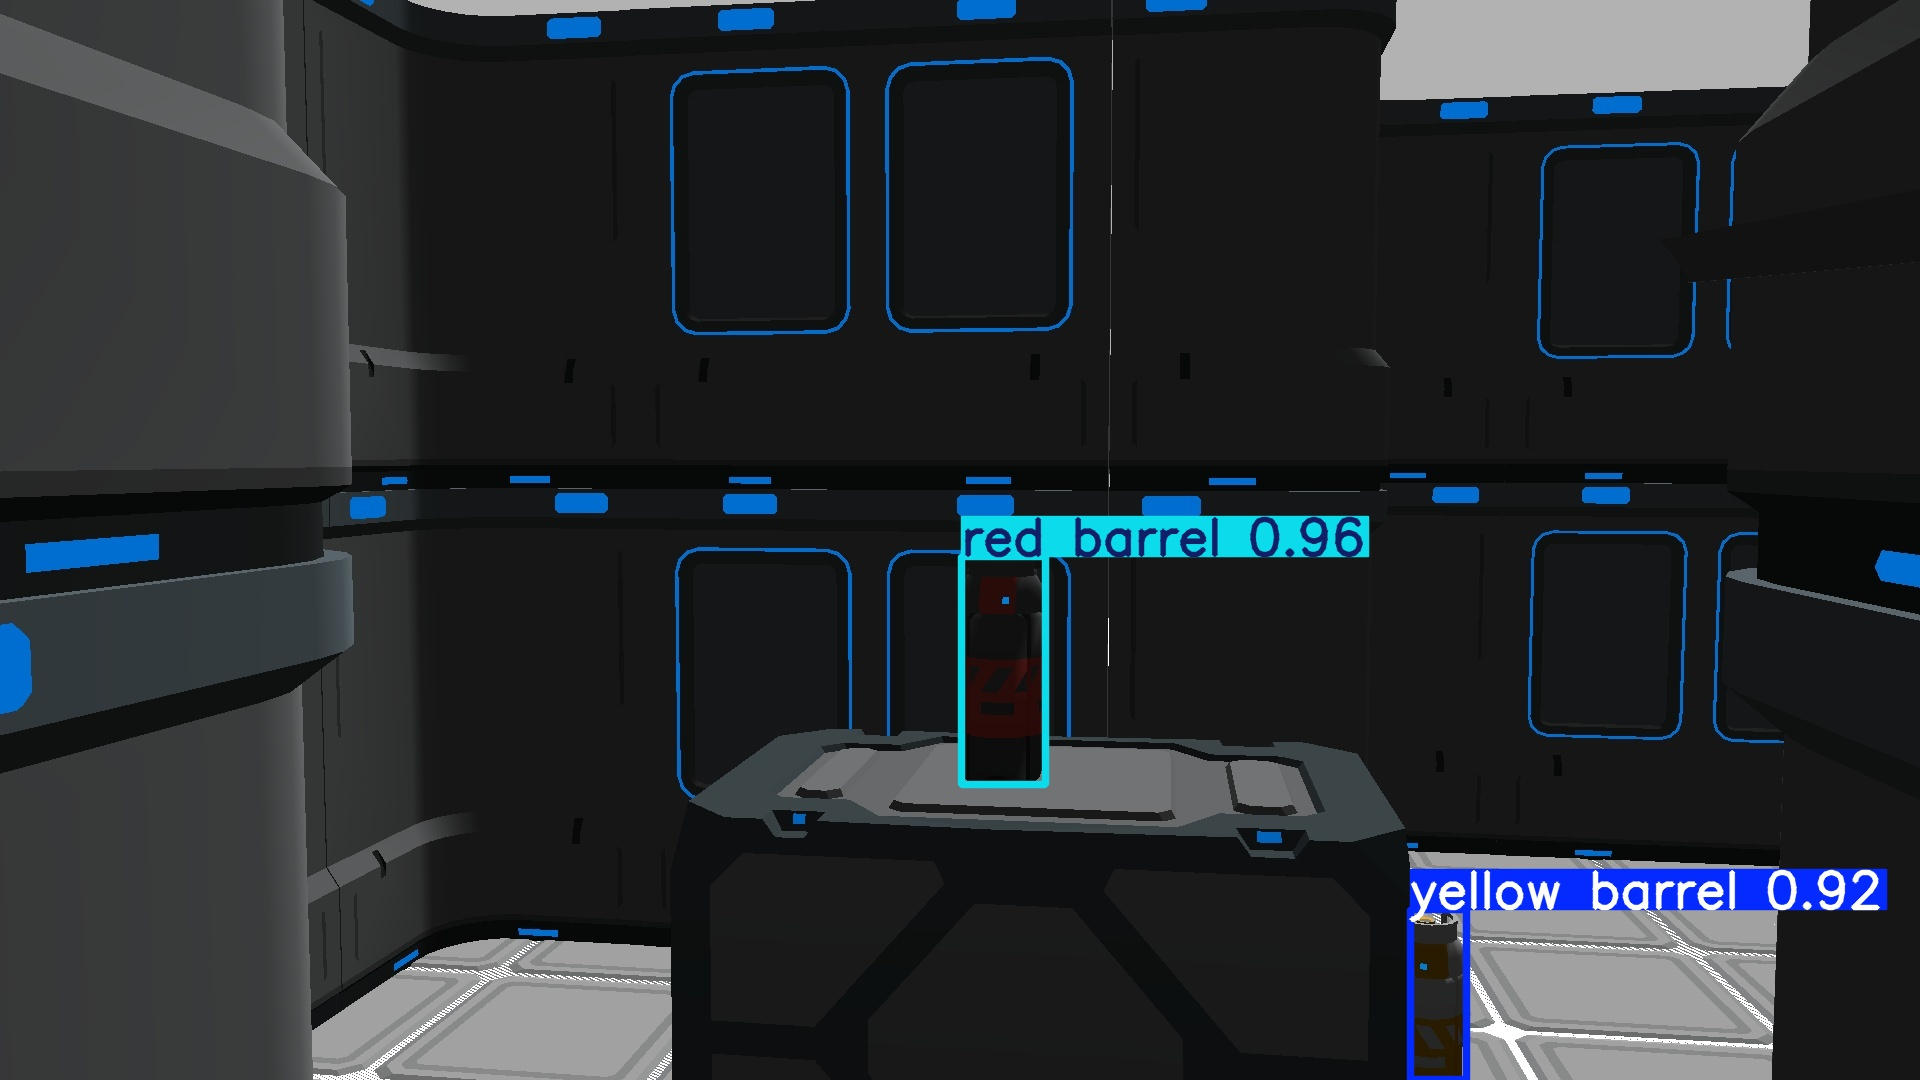

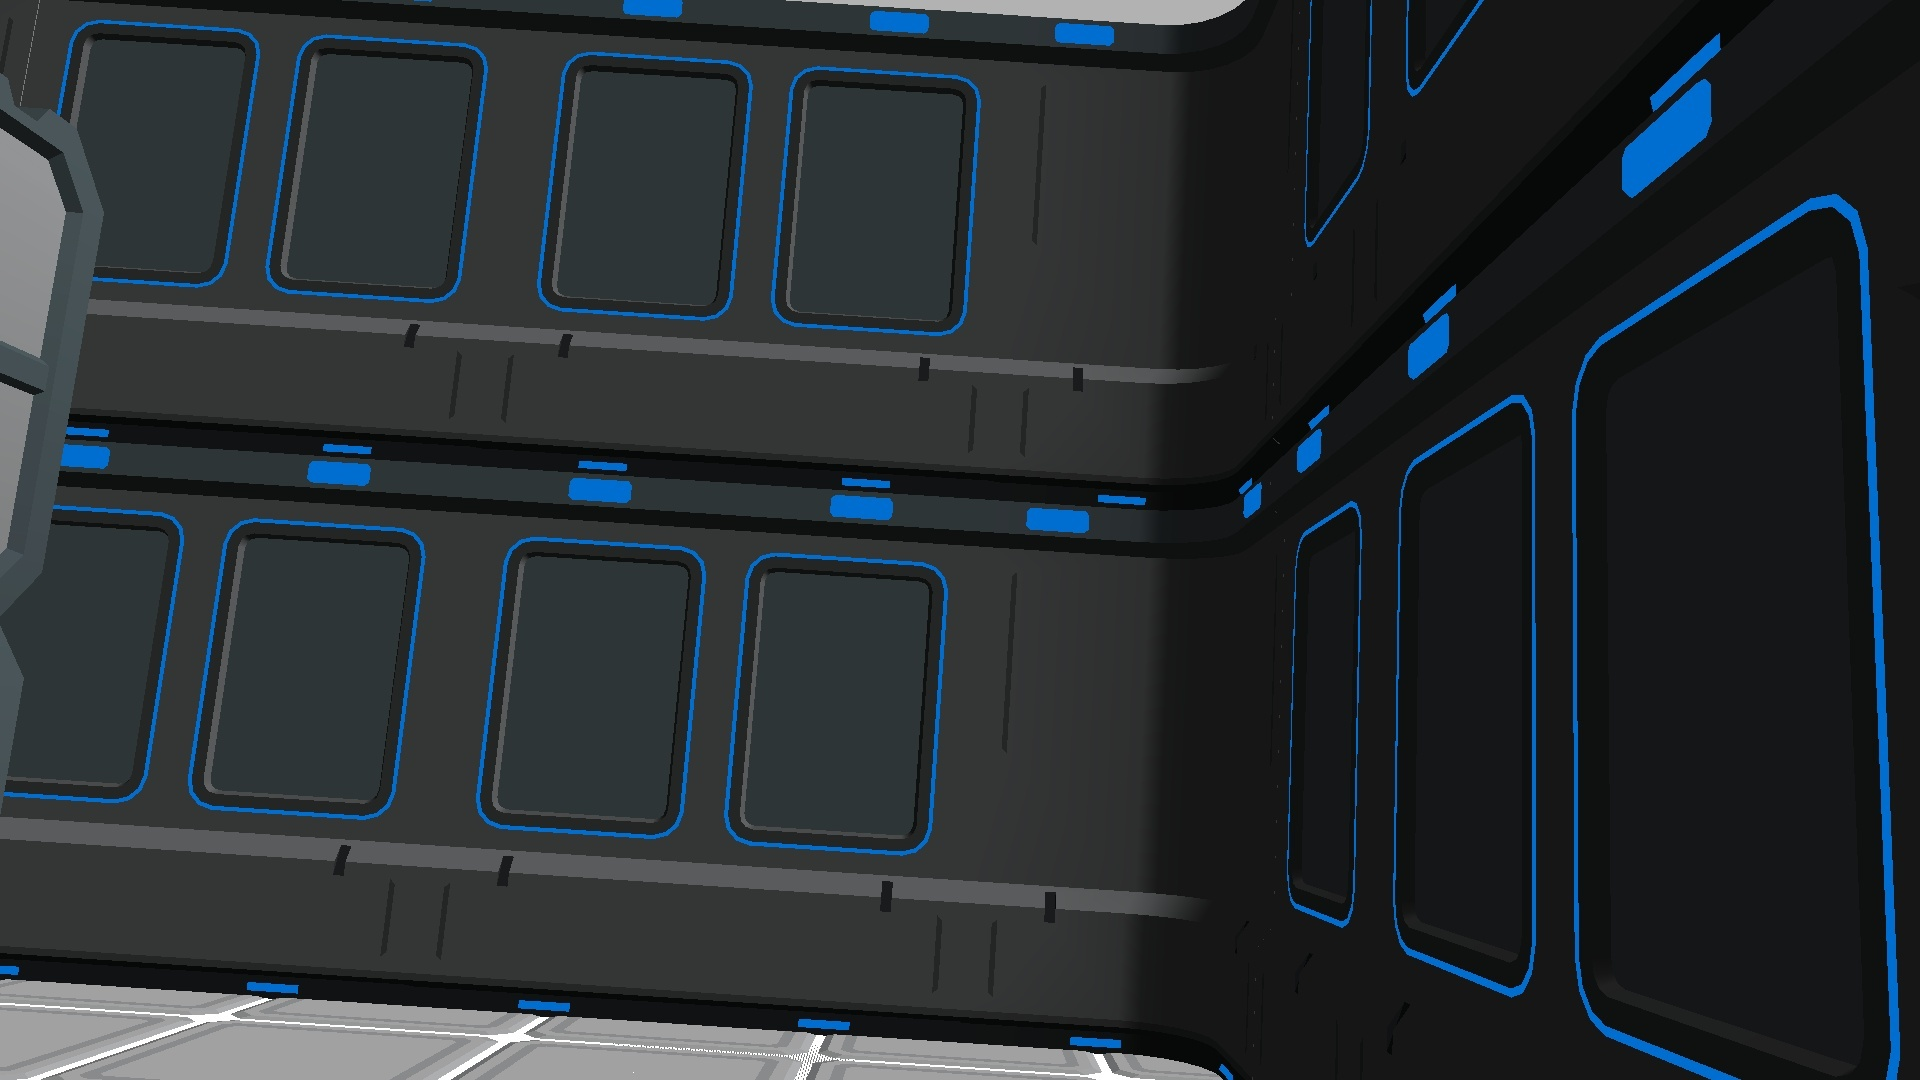

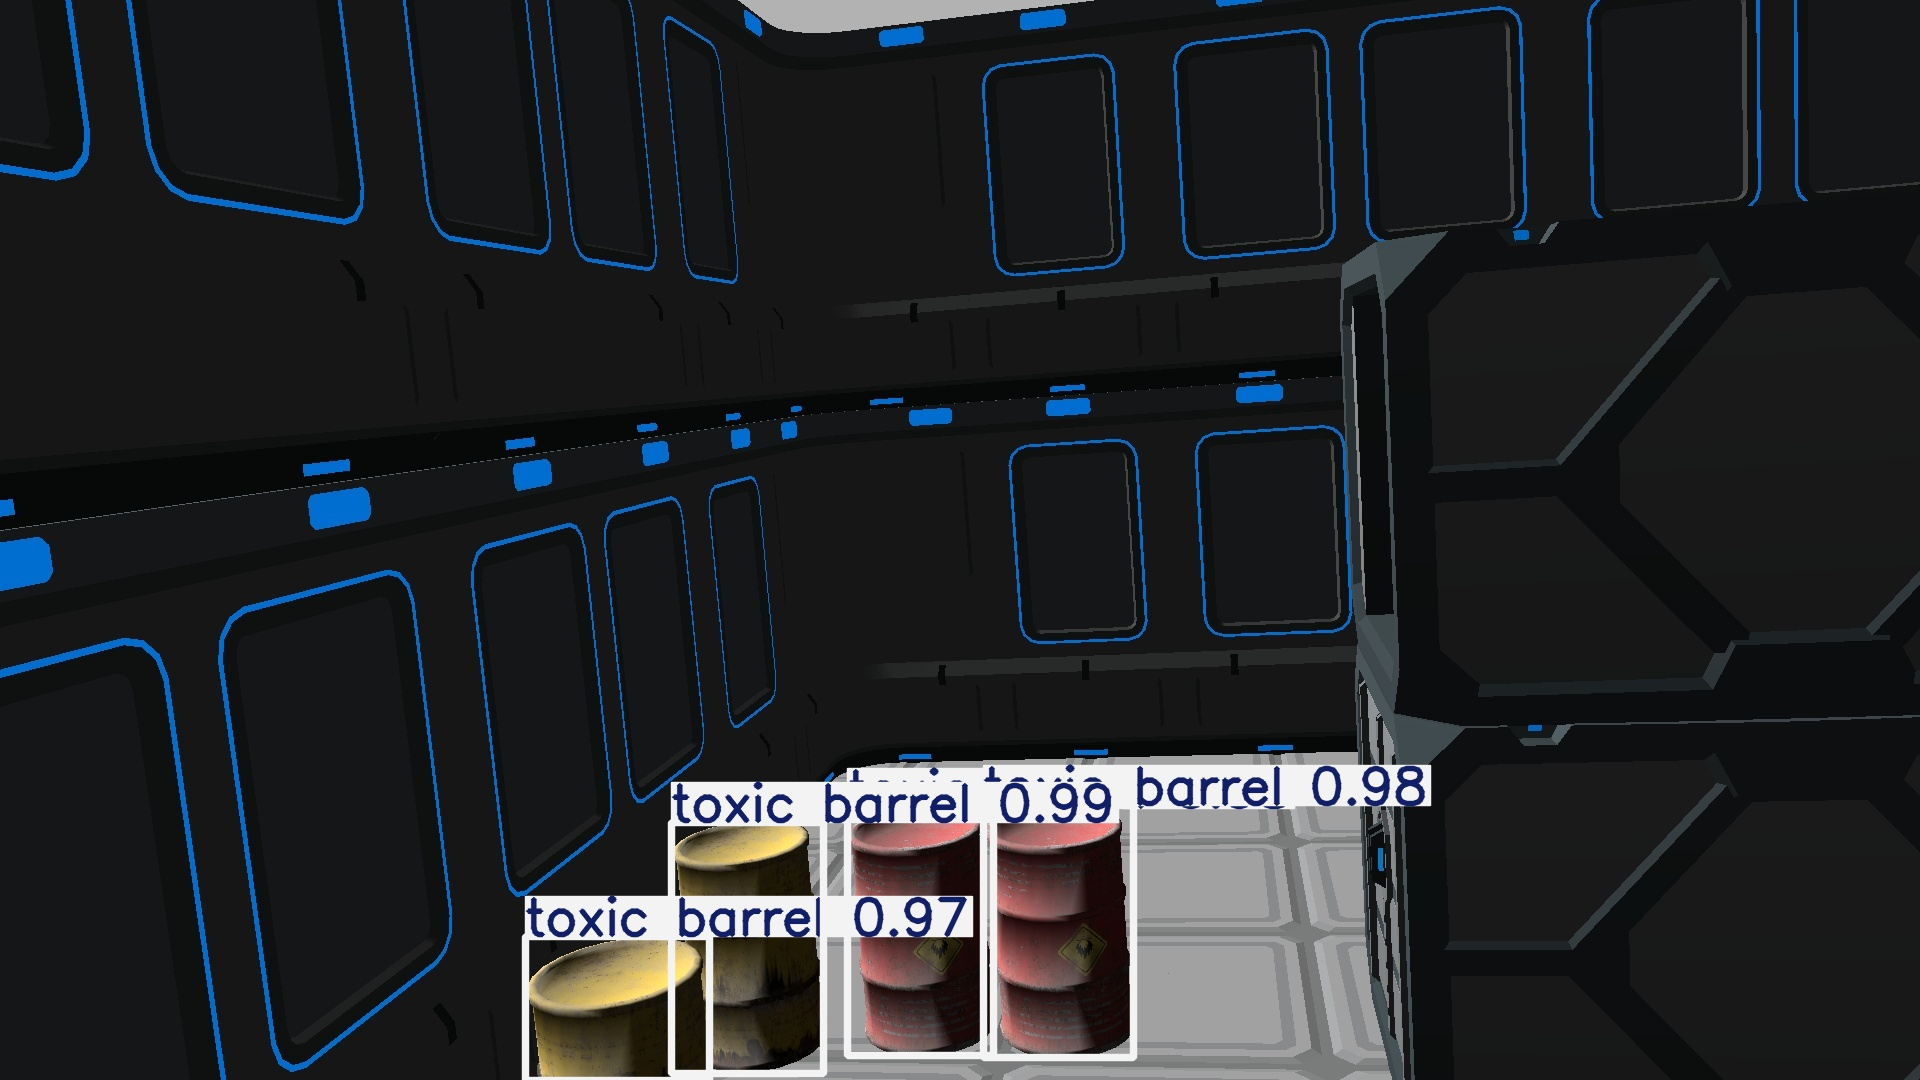

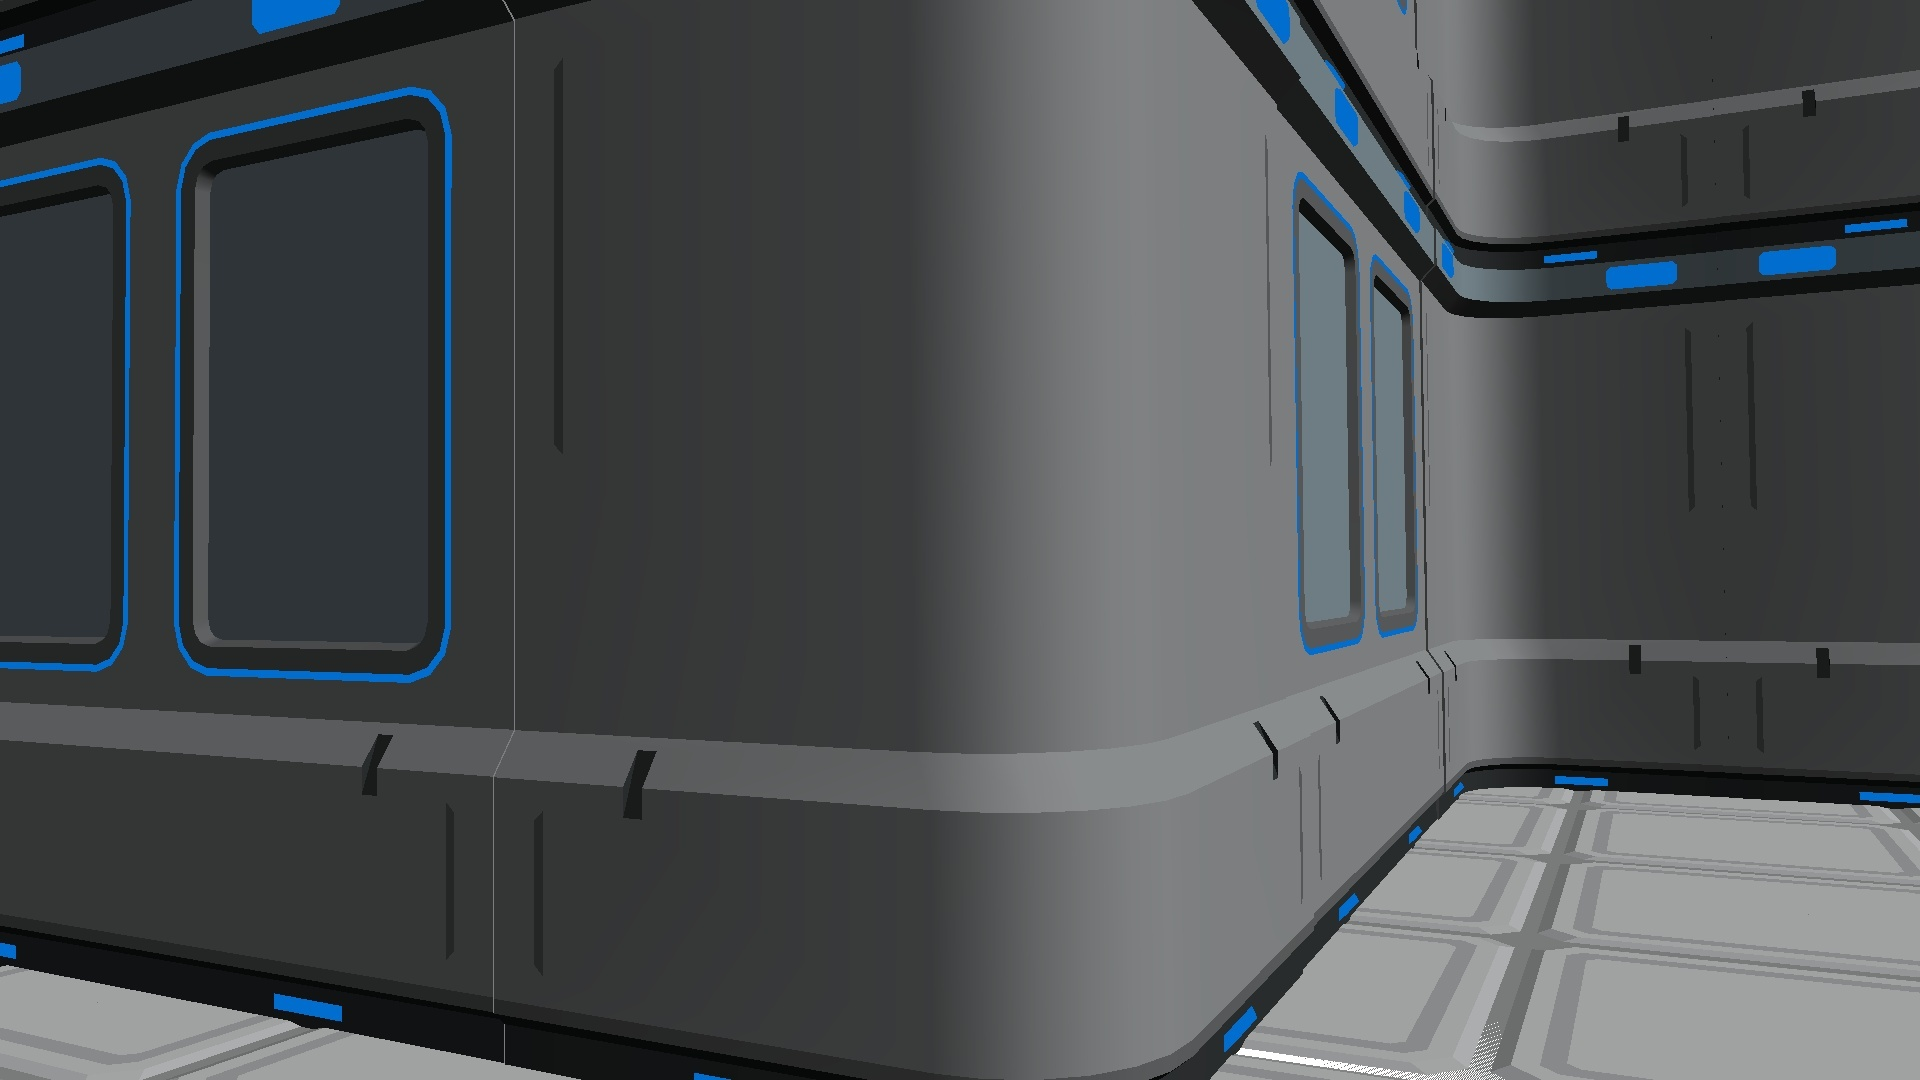

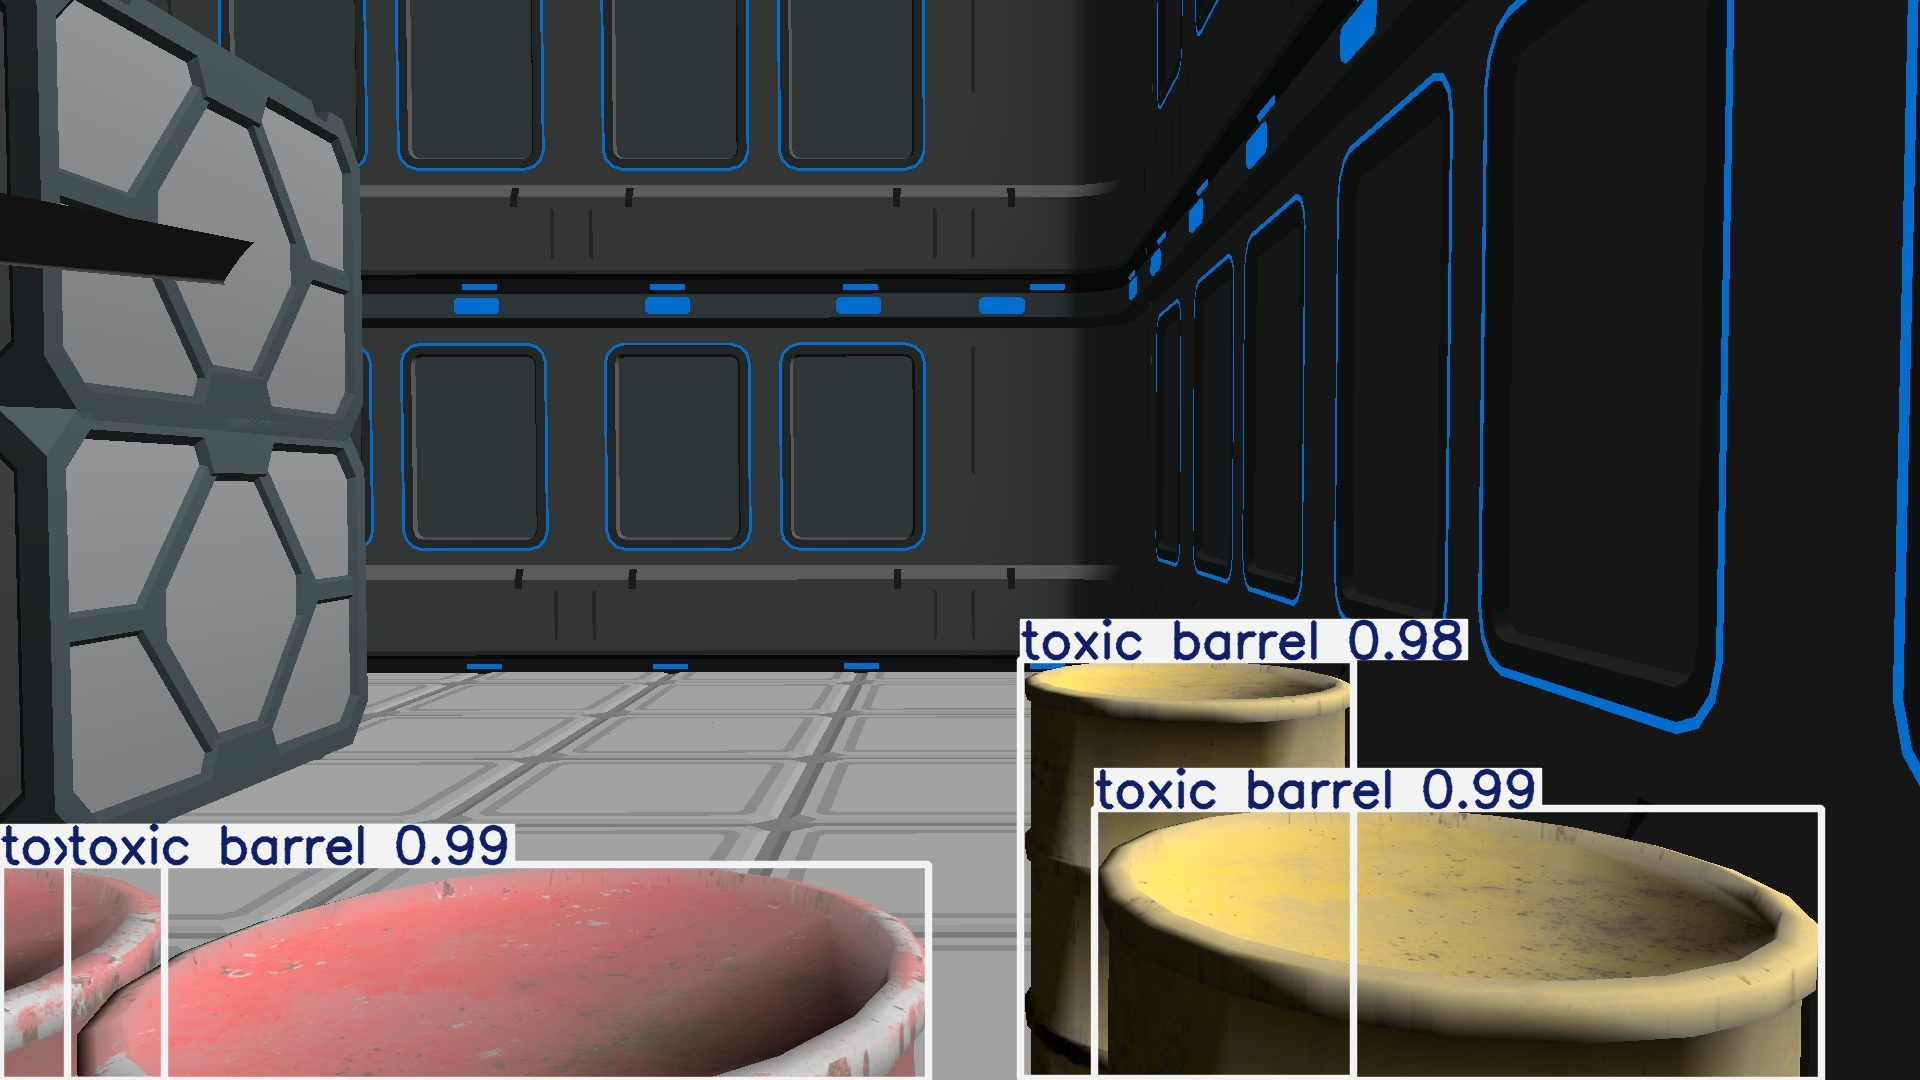

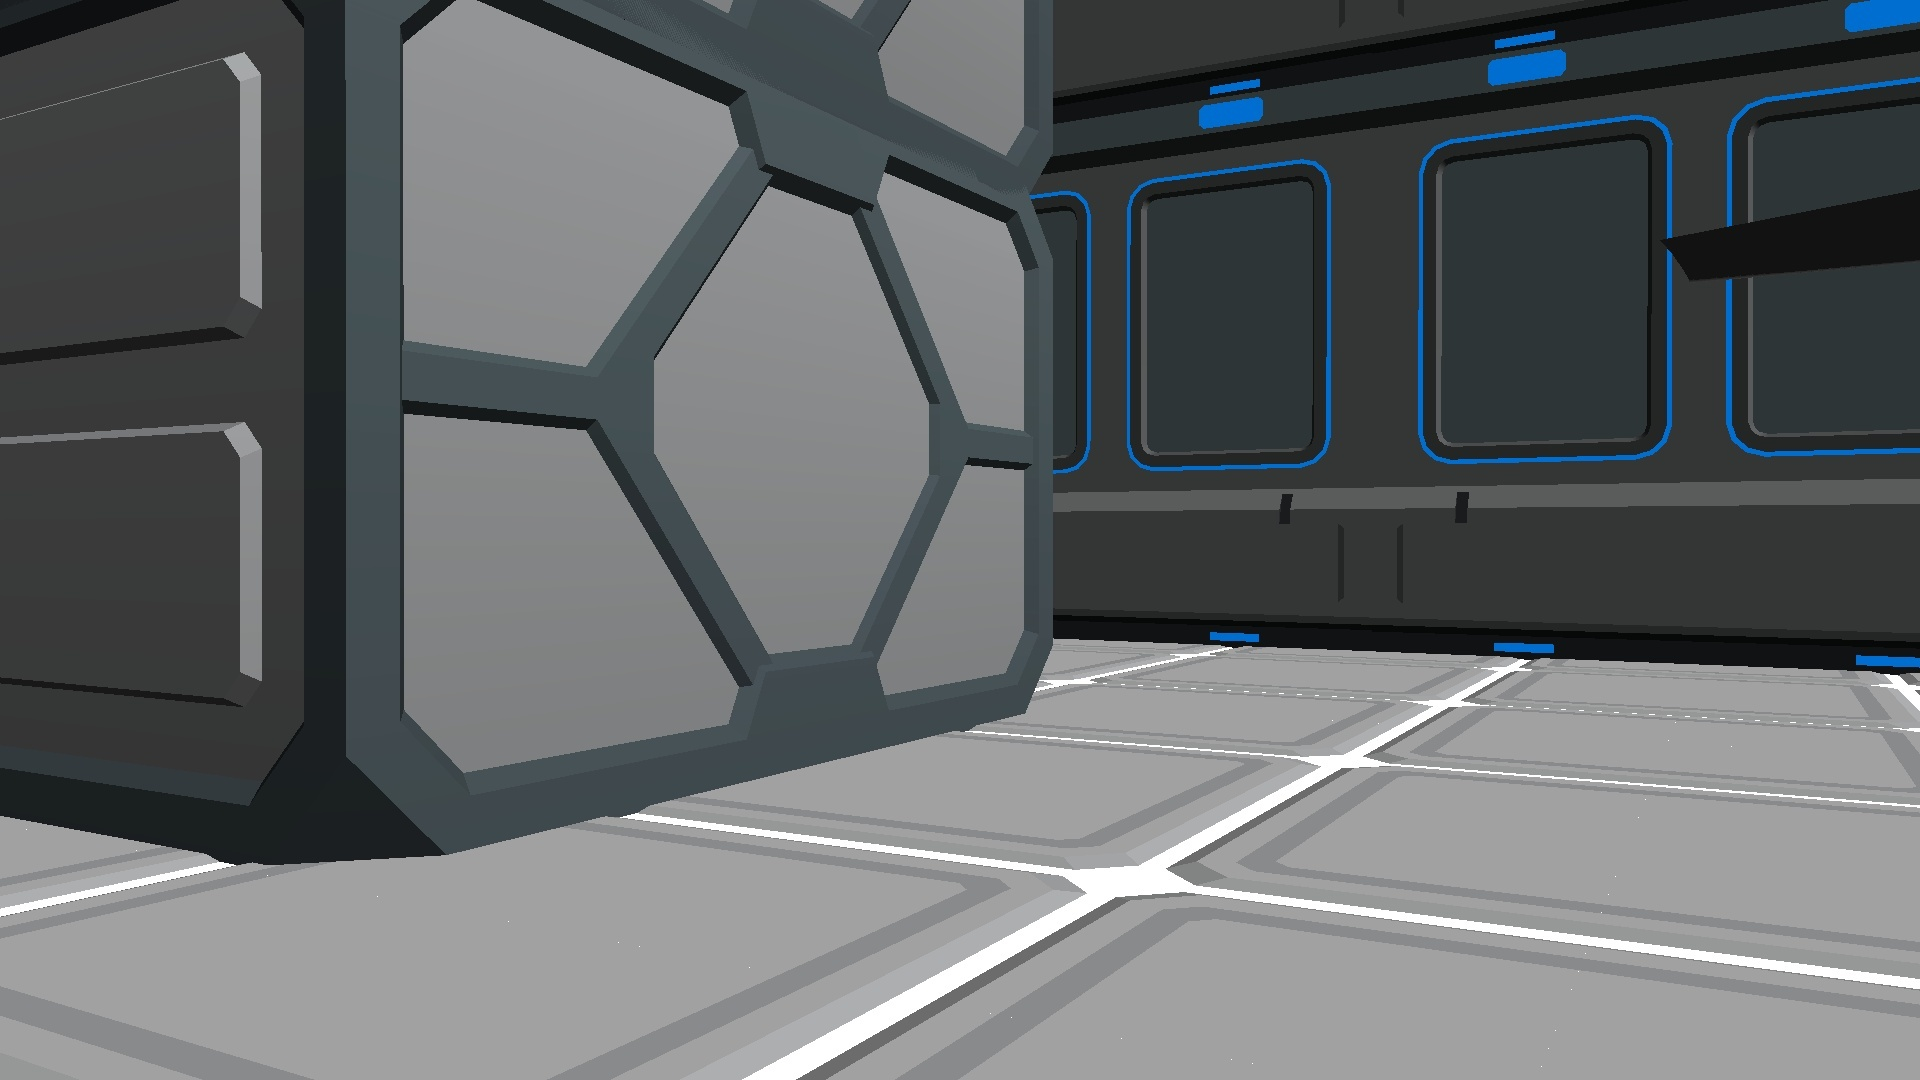

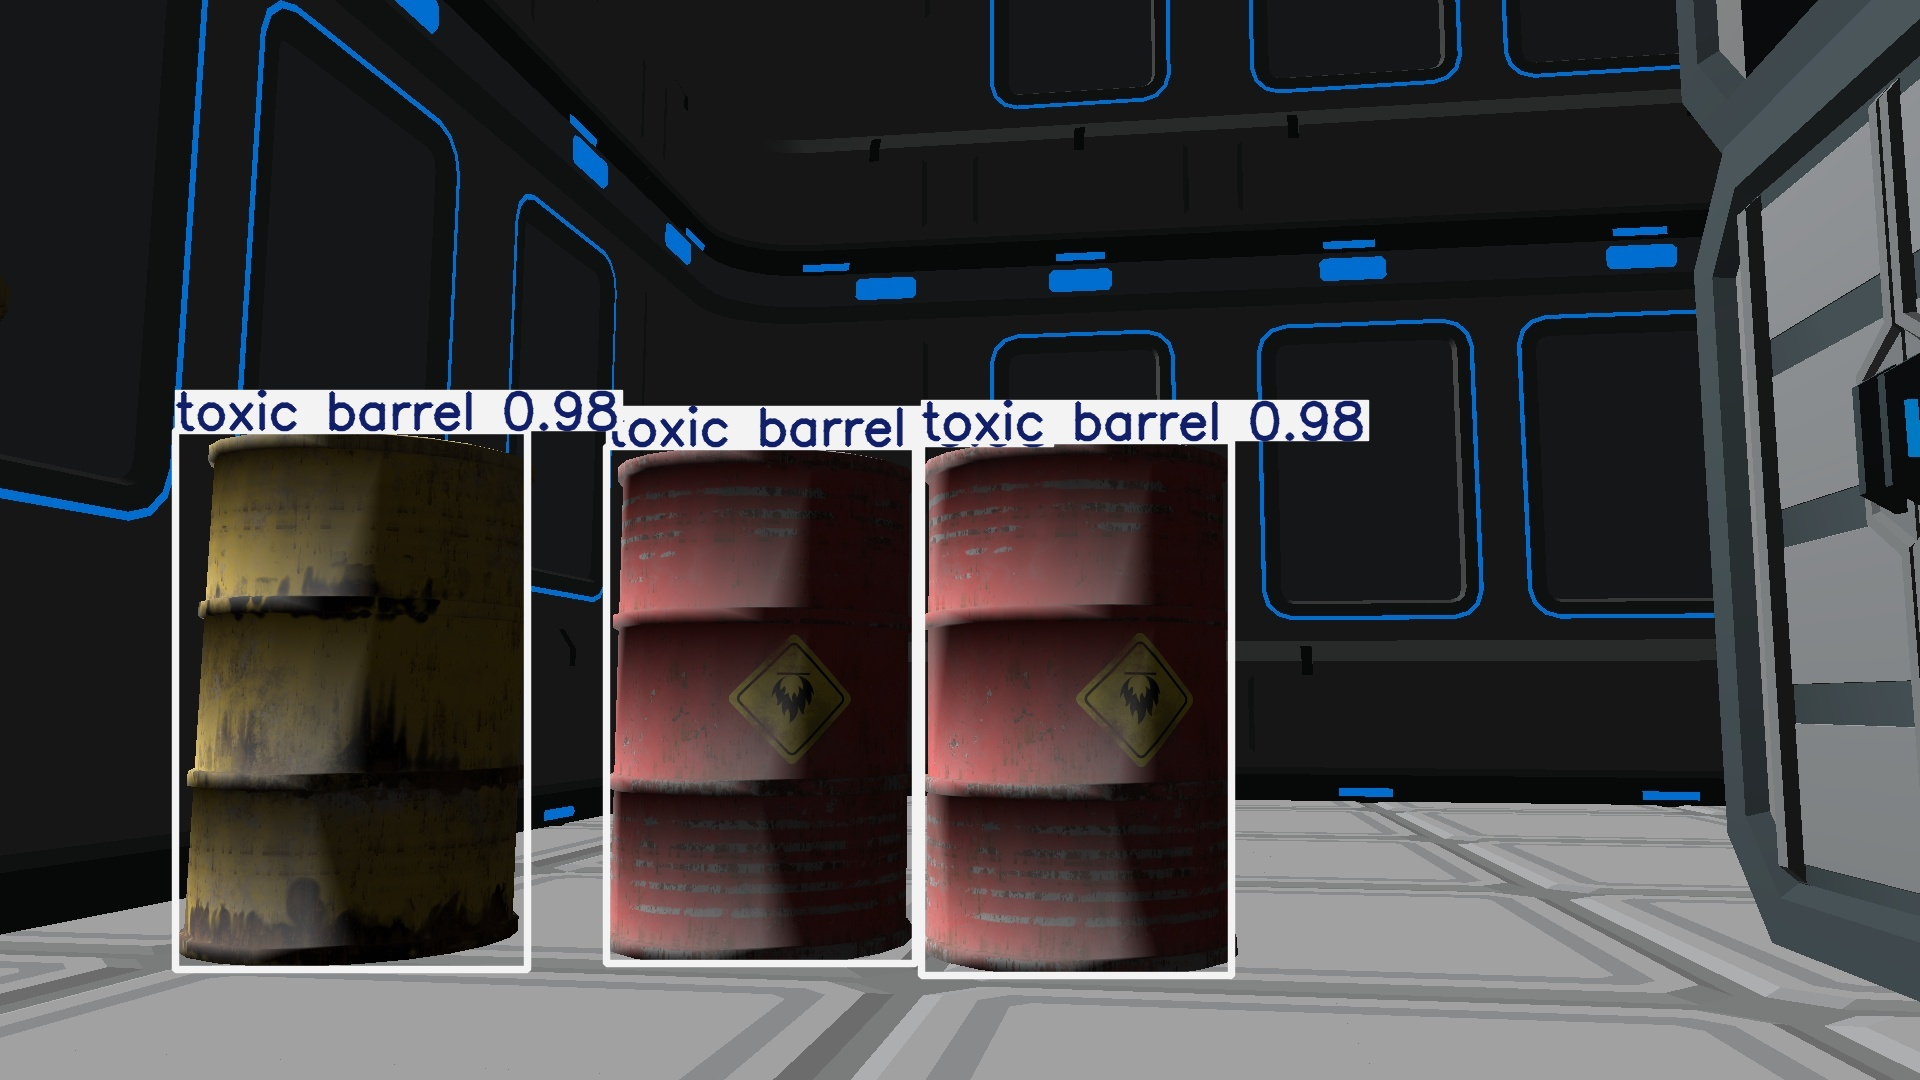

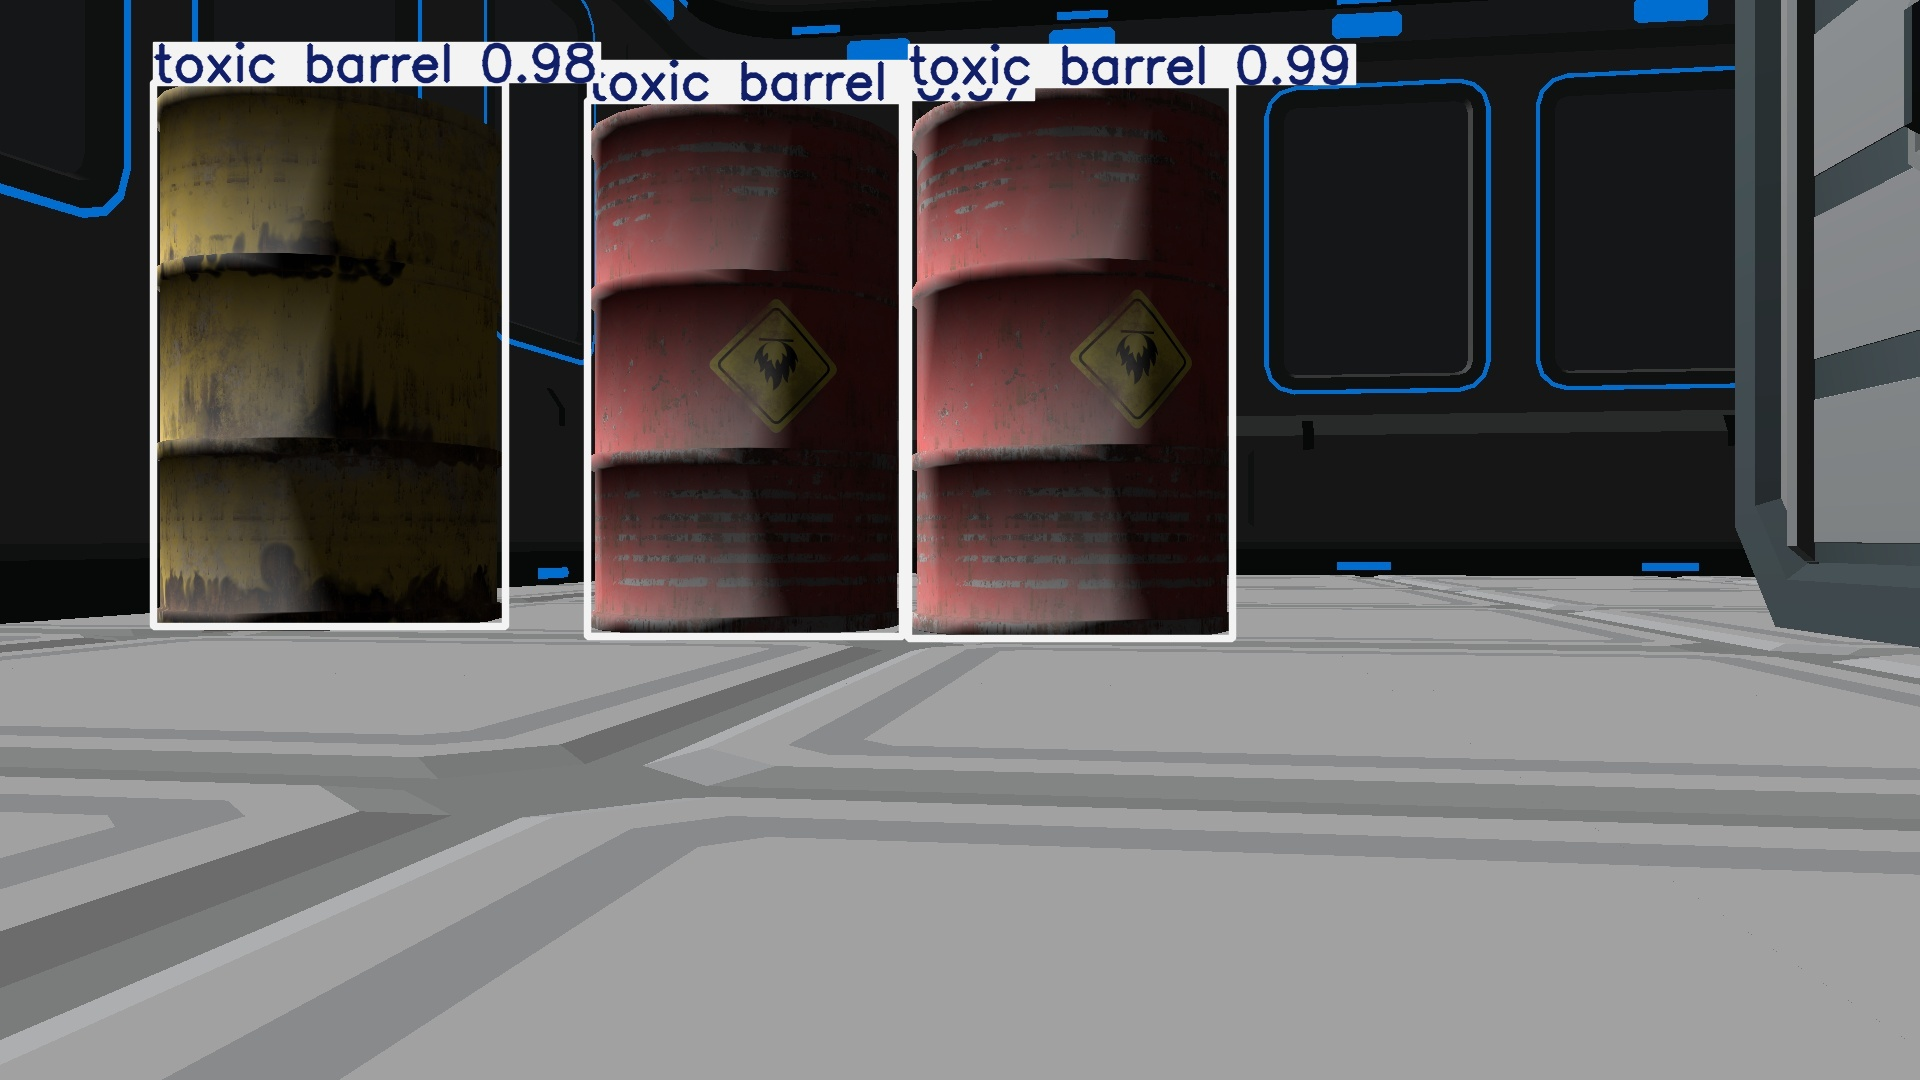

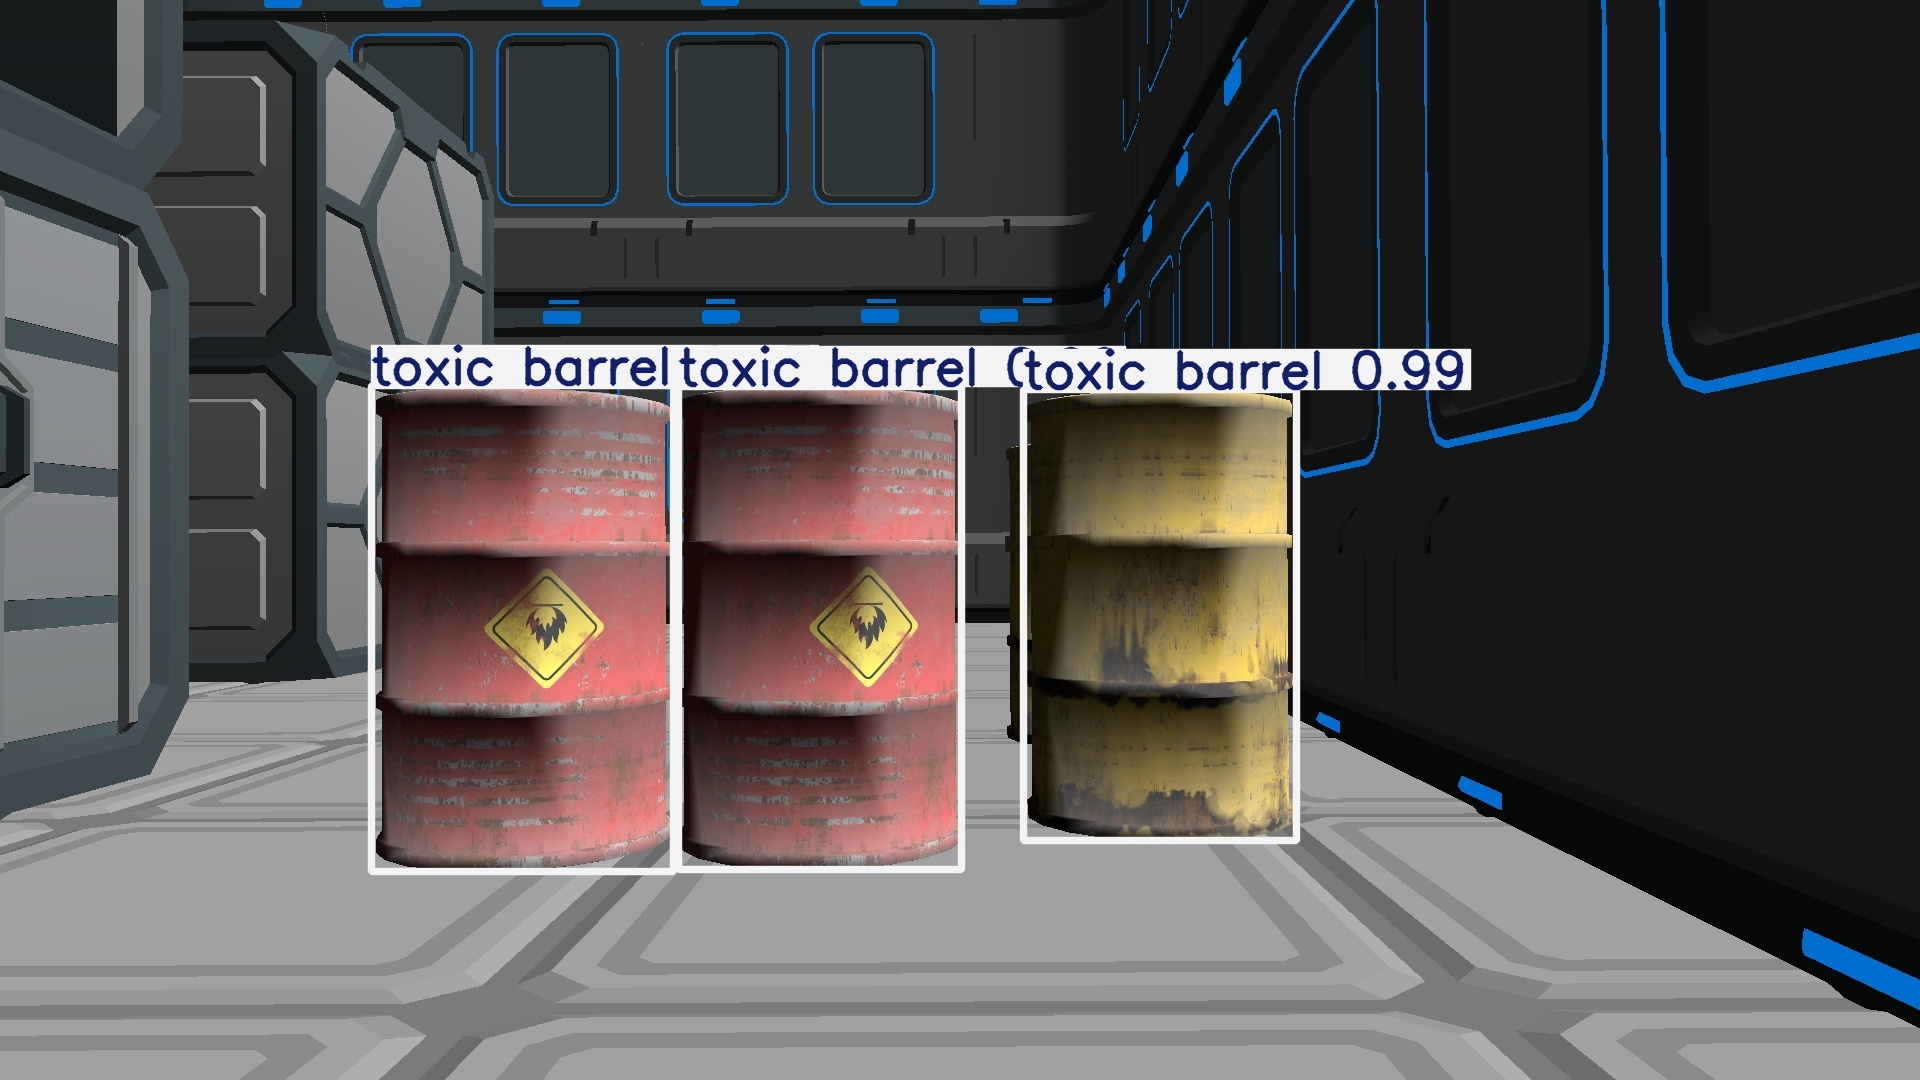

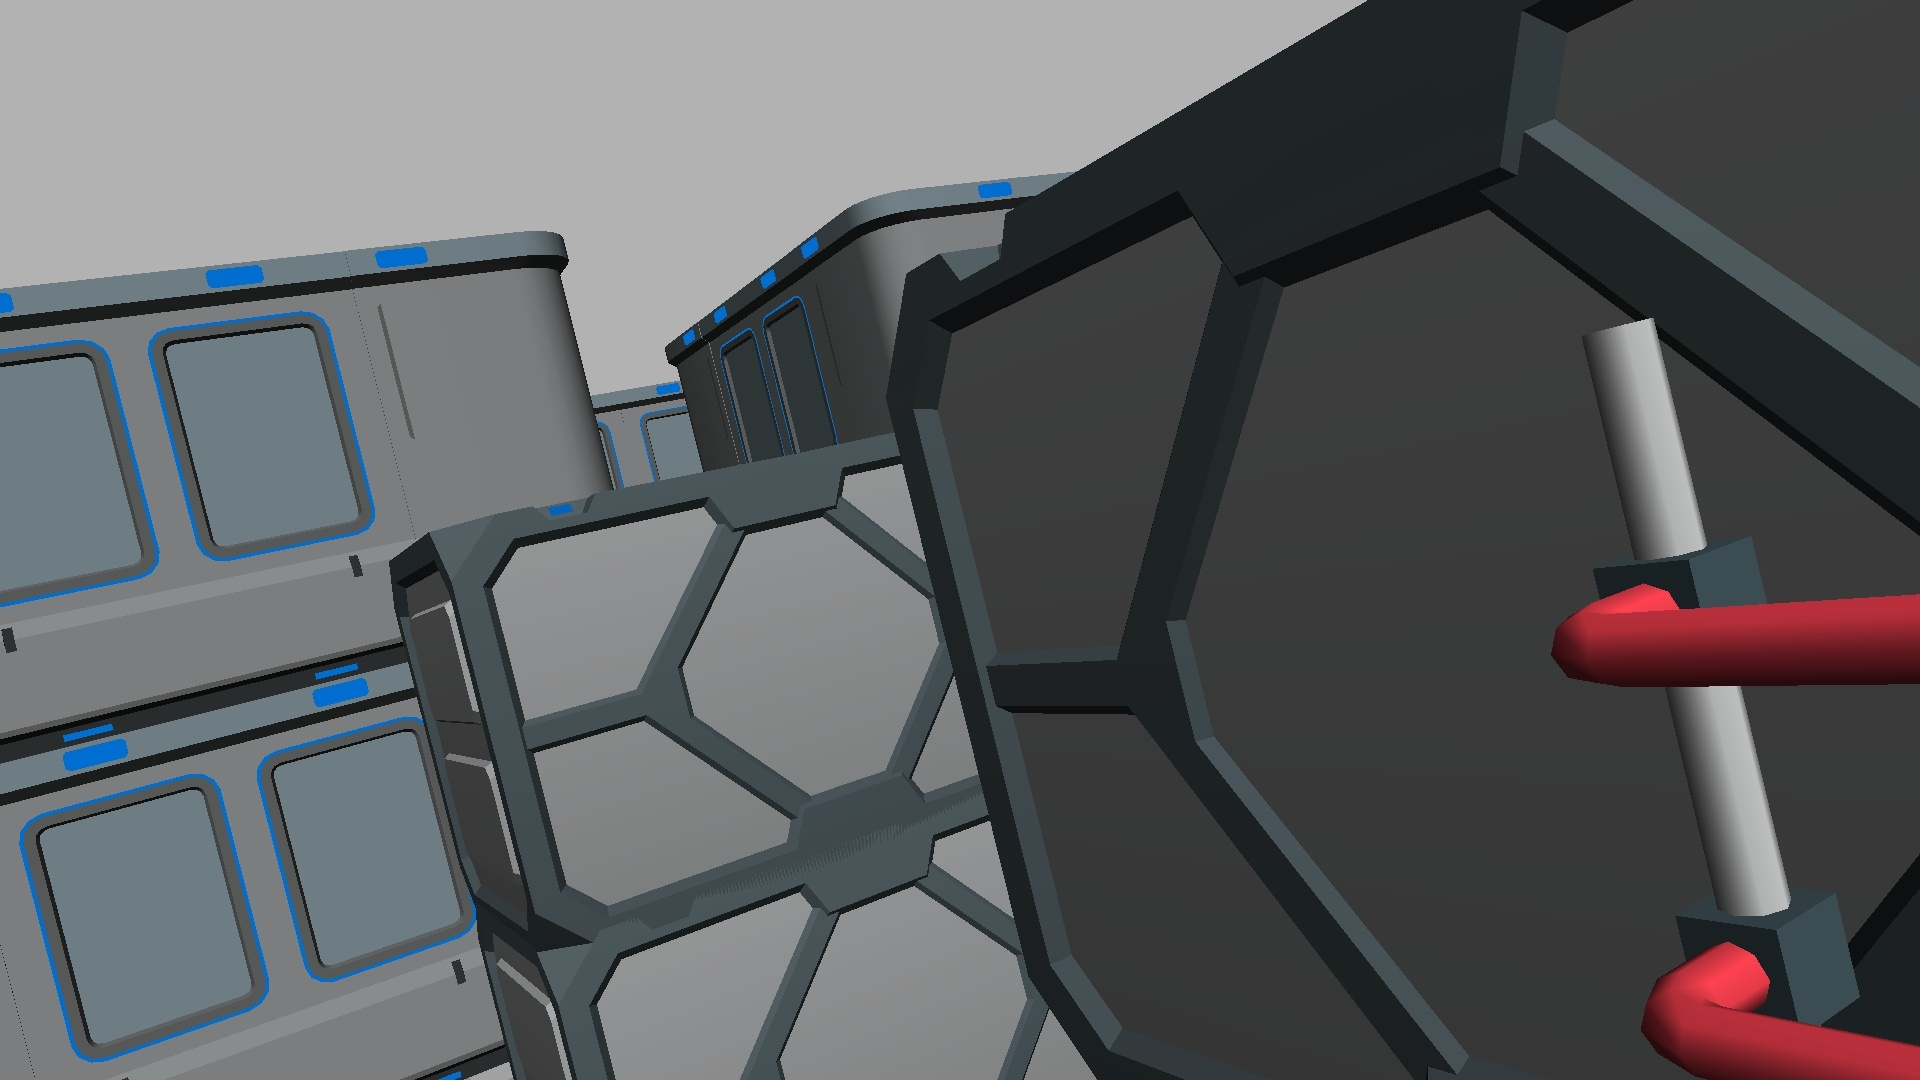

In [9]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')


The model should draw a box around each object of interest in each image. If it isn't doing a good job of detecting objects, here are a few tips:

1. Double-check your dataset to make sure there are no labeling errors or conflicting examples.
2. Increase the number of epochs used for training.
3. Use a larger model size (e.g. `yolov8l.pt`).
4. Add more images to the training dataset. See my [dataset video](https://www.youtube.com/watch?v=v0ssiOY6cfg) for tips on how to capture good training images and improve accuracy.

You can also run the model on video files or other images images by uploading them to this notebook and using the above `!yolo detect predict` command, where `source` points to the location of the video file, image, or folder of images. The results will be saved in `runs/detect/predict`.

Drawing boxes on images is great, but it isn't very useful in itself. It's also not very helpful to just run this models inside a Colab notebook: it's easier if we can just run it on a local computer. Continue to the next section to see how to download your newly trained model and run it on a local device.

#7.&nbsp;Deploy Model

Now that your custom model has been trained, it's ready to be downloaded and deployed in an application! YOLO models can run on a wide variety of hardware, including PCs, embedded systems, and phones. Ultralytics makes it easy to convert the YOLO models to various formats (`tflite`, `onnx`, etc.) and deploy them in a variety of environments.

You need to export the model in onnx format for use onnxdetector which can work with hula python environment.

This section shows how to download the model and provides links to instructions for deploying it for use on onnxdetector.

In [10]:
!yolo export model=runs/detect/train/weights/best.pt format=onnx opset=12 # creates 'best.onnx'

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 209ms
Prepared 4 packages in 1.50s
Installed 4 packages in 290ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 2.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 

## 7.1a Download YOLO Model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later. It then zips the folder as `my_model.zip`.

In [11]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp /content/runs/detect/train/weights/best.onnx /content/my_model/best.onnx
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip /content/my_model.zip best.onnx
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 9%)
  adding: best.onnx (deflated 14%)
  adding: train/ (stored 0%)
  adding: train/args.yaml (deflated 53%)
  adding: train/val_batch0_labels.jpg (deflated 13%)
  adding: train/results.png (deflated 8%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/best.pt (deflated 9%)
  adding: train/weights/last.pt (deflated 9%)
  adding: train/weights/best.onnx (deflated 14%)
  adding: train/BoxP_curve.png (deflated 19%)
  adding: train/train_batch422.jpg (deflated 21%)
  adding: train/BoxR_curve.png (deflated 16%)
  adding: train/val_batch2_pred.jpg (deflated 11%)
  adding: train/BoxPR_curve.png (deflated 27%)
  adding: train/confusion_matrix.png (deflated 29%)
  adding: train/train_batch421.jpg (deflated 22%)
  adding: train/results.csv (deflated 63%)
  adding: train/val_batch2_labels.jpg (deflated 11%)
  adding: train/labels.jpg (deflated 34%)
  adding: train/val_batch1_labels.jpg (deflated 14%)
  adding: train/train_batch1.jpg (d

In [12]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## OR 7.1b Download YOLO Model via Colab

Download best.onnx file from the Google Colab instance by clicking the "Files" icon on the left hand side of the browser, and then navigate to runs/detect/train/weights/best.onnx and click Download beside the best.onnx.

## 7.2 Deploy YOLO Model on your Windows laptop

Next, we'll take our downloaded model and run it with onnxdetector.

I wrote a sample python script, `onnxtry.py` shown below, that shows how to load a model, run inference on video streamed by hula drone, parse the inference results, and display boxes around each detected class in the image. Change the modeltouse to your onnx file name
```
import pyhula
import time
import math
from hula_video import hula_video
from onnxdetector import onnxdetector
from datetime import datetime, timedelta
import cv2
import numpy as np

modelfiletouse = "best.onnx"
uapi = pyhula.UserApi()
if not uapi.connect():
    print('connect error')
else:
    print('success')
    video = hula_video(hula_api=uapi,display=False)
    detector = onnxdetector(model=modelfiletouse,label="classes.txt")
    print("loaded model")
    video.video_mode_on()
    print("video on")
    for i in range(50):
        frame = video.get_video()
        object_found, frame = detector.detect(frame)
        if not object_found is None:
            target_x = object_found['x']
            target_y = object_found['y']
            print(object_found)
            print(target_x)
            print(target_y)
        cv2.imshow("Target Detection", frame)
        print(F"detected objects: {detector.get_detected_obj()}")
        cv2.waitKey(1)
    cv2.destroyAllWindows()
    video.close()
```



# Appendix: Common Errors

If you run into any errors working through this notebook, please do the following:


- Double-check that the dataset files are set up in the correct folder structure
- Make sure there are no typos or errors in your labelmap file
- Google search the error to look for solutions
